# NBA Players EDA — players_merged.csv
Exploratory Data Analysis on 508 NBA players across 30 teams.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('data/players_merged.csv')
print(df.shape)
df.head()

(508, 33)


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,...,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,PACE,PIE,POSITION
0,1630639,A.J. Lawson,TOR,24.0,26,18.7,9.1,3.3,1.2,0.5,...,0.036,0.128,0.080,5.7,0.508,0.542,0.189,103.71,0.082,NaN
1,1631260,AJ Green,MIL,25.0,73,22.7,7.4,2.4,1.5,0.5,...,0.011,0.087,0.051,6.9,0.612,0.621,0.123,100.84,0.058,NaN
2,1642358,AJ Johnson,WAS,20.0,29,22.0,7.6,2.0,2.6,0.4,...,0.011,0.073,0.042,10.3,0.441,0.480,0.173,100.83,0.053,NaN
3,203932,Aaron Gordon,DEN,29.0,51,28.4,14.7,4.8,3.2,0.5,...,0.060,0.109,0.086,9.0,0.607,0.650,0.186,101.64,0.104,NaN
4,1628988,Aaron Holiday,HOU,28.0,62,12.8,5.5,1.3,1.3,0.3,...,0.015,0.073,0.044,9.1,0.571,0.594,0.162,103.09,0.082,NaN


## 1. Data Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PLAYER_ID          508 non-null    int64  
 1   PLAYER_NAME        508 non-null    object 
 2   TEAM_ABBREVIATION  508 non-null    object 
 3   AGE                508 non-null    float64
 4   GP                 508 non-null    int64  
 5   MIN                508 non-null    float64
 6   PTS                508 non-null    float64
 7   REB                508 non-null    float64
 8   AST                508 non-null    float64
 9   STL                508 non-null    float64
 10  BLK                508 non-null    float64
 11  TOV                508 non-null    float64
 12  FG_PCT             508 non-null    float64
 13  FG3_PCT            508 non-null    float64
 14  FT_PCT             508 non-null    float64
 15  OREB               508 non-null    float64
 16  DREB               508 non

In [3]:
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
PLAYER_ID,508.000000,1415474.403543,514777.844291,2544.000000,1628380.750000,1630216.000000,1631221.250000,1642530.000000
AGE,508.000000,26.348425,4.316230,19.000000,23.000000,25.000000,29.000000,40.000000
GP,508.000000,51.204724,20.802950,10.000000,35.000000,55.000000,70.000000,82.000000
MIN,508.000000,20.572441,9.109883,2.400000,13.275000,20.450000,27.900000,37.700000
PTS,508.000000,9.560433,6.539948,0.700000,4.475000,8.200000,12.700000,32.700000
REB,508.000000,3.797047,2.401900,0.200000,2.100000,3.300000,4.900000,13.900000
AST,508.000000,2.224409,1.840213,0.000000,1.000000,1.600000,2.900000,11.600000
STL,508.000000,0.709843,0.406240,0.000000,0.400000,0.700000,0.900000,3.000000
BLK,508.000000,0.429528,0.404358,0.000000,0.200000,0.300000,0.500000,3.800000
TOV,508.000000,1.163189,0.826701,0.100000,0.600000,0.900000,1.525000,4.700000


## 2. Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0]
print('Columns with missing values:')
display(missing_df)
print('\nNote: POSITION column is entirely empty — excluded from analysis.')

Columns with missing values:


,missing_count,missing_pct
POSITION,508,100.0



Note: POSITION column is entirely empty — excluded from analysis.


## 3. Key Stat Distributions

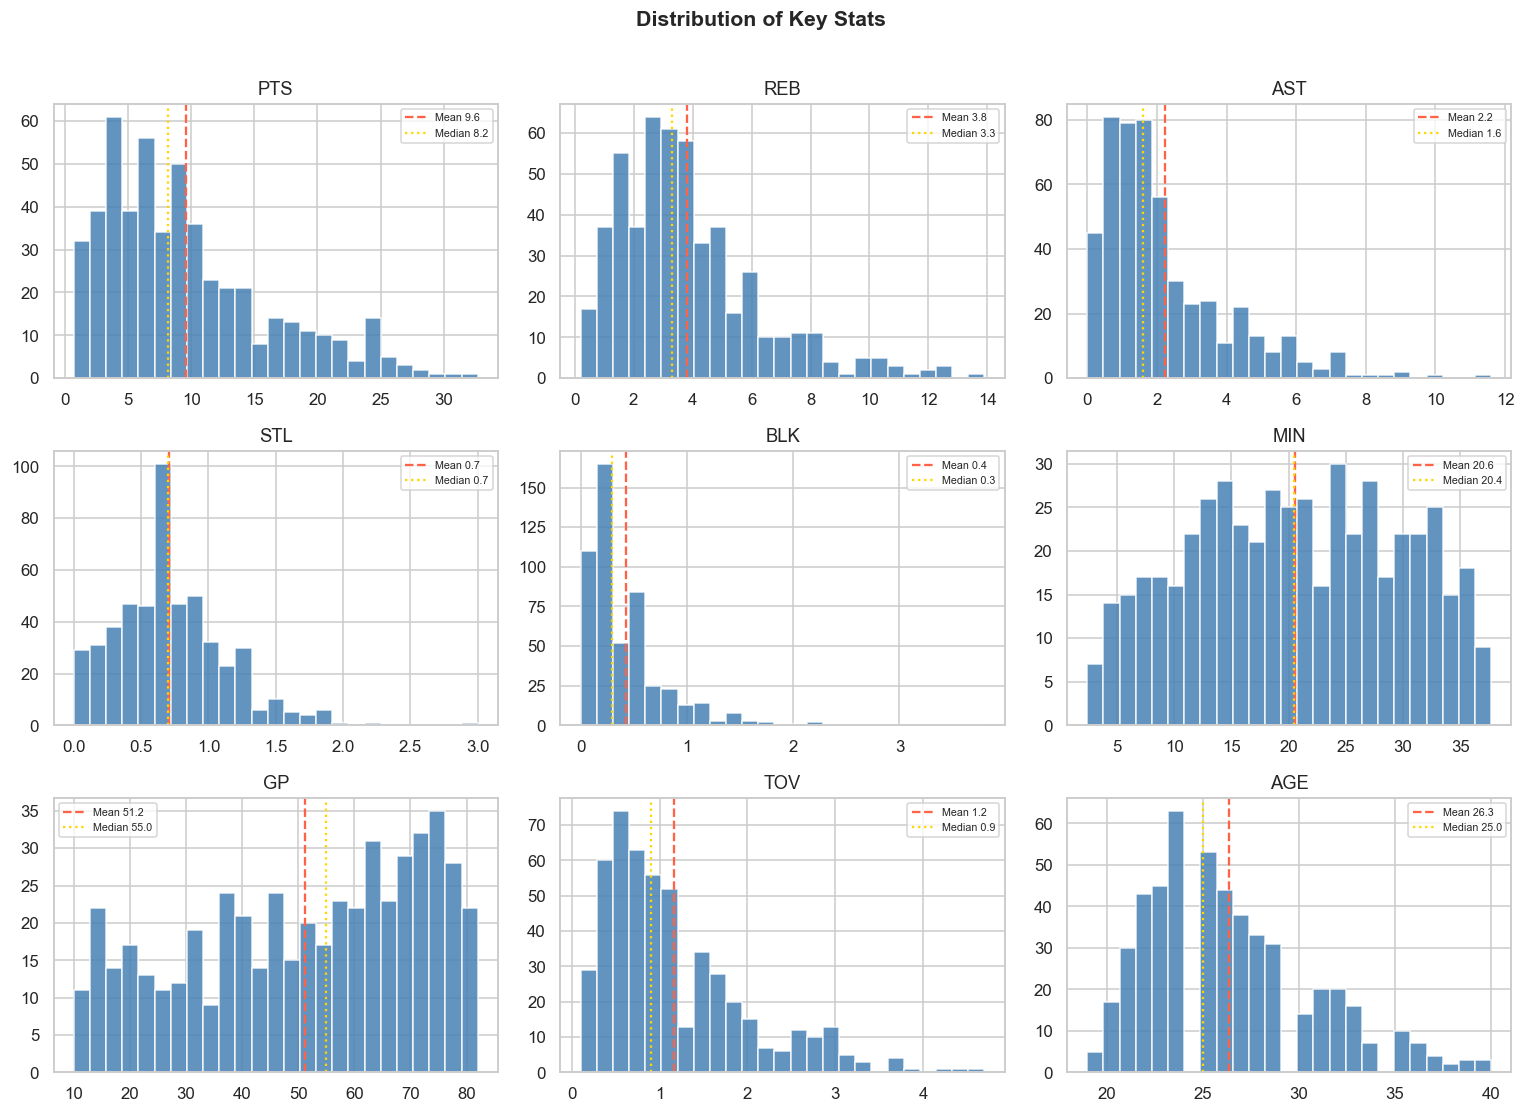

In [5]:
stat_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'MIN', 'GP', 'TOV', 'AGE']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Distribution of Key Stats', fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes.flat, stat_cols):
    data = df[col].dropna()
    ax.hist(data, bins=25, edgecolor='white', color='steelblue', alpha=0.85)
    ax.axvline(data.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean {data.mean():.1f}')
    ax.axvline(data.median(), color='gold', linestyle=':', linewidth=1.5, label=f'Median {data.median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4. Shooting Efficiency

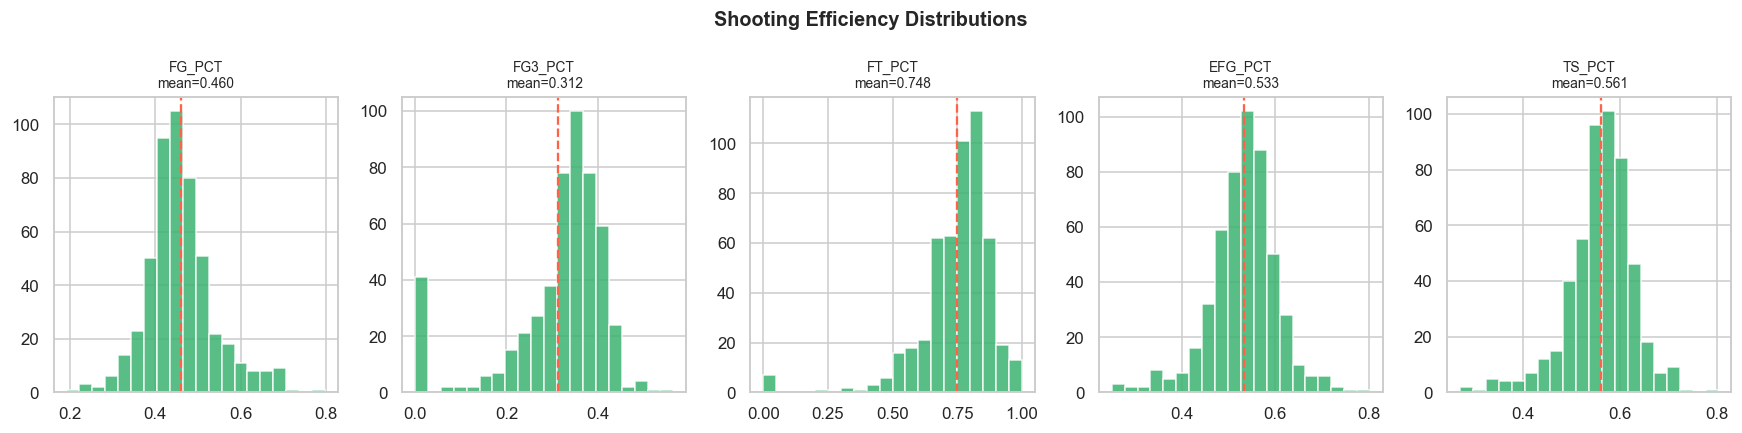

In [5]:
eff_cols = ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'EFG_PCT', 'TS_PCT']

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Shooting Efficiency Distributions', fontsize=13, fontweight='bold')

for ax, col in zip(axes, eff_cols):
    data = df[col].dropna()
    ax.hist(data, bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='tomato', linestyle='--', linewidth=1.5)
    ax.set_title(f'{col}\nmean={data.mean():.3f}', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Correlation Matrix

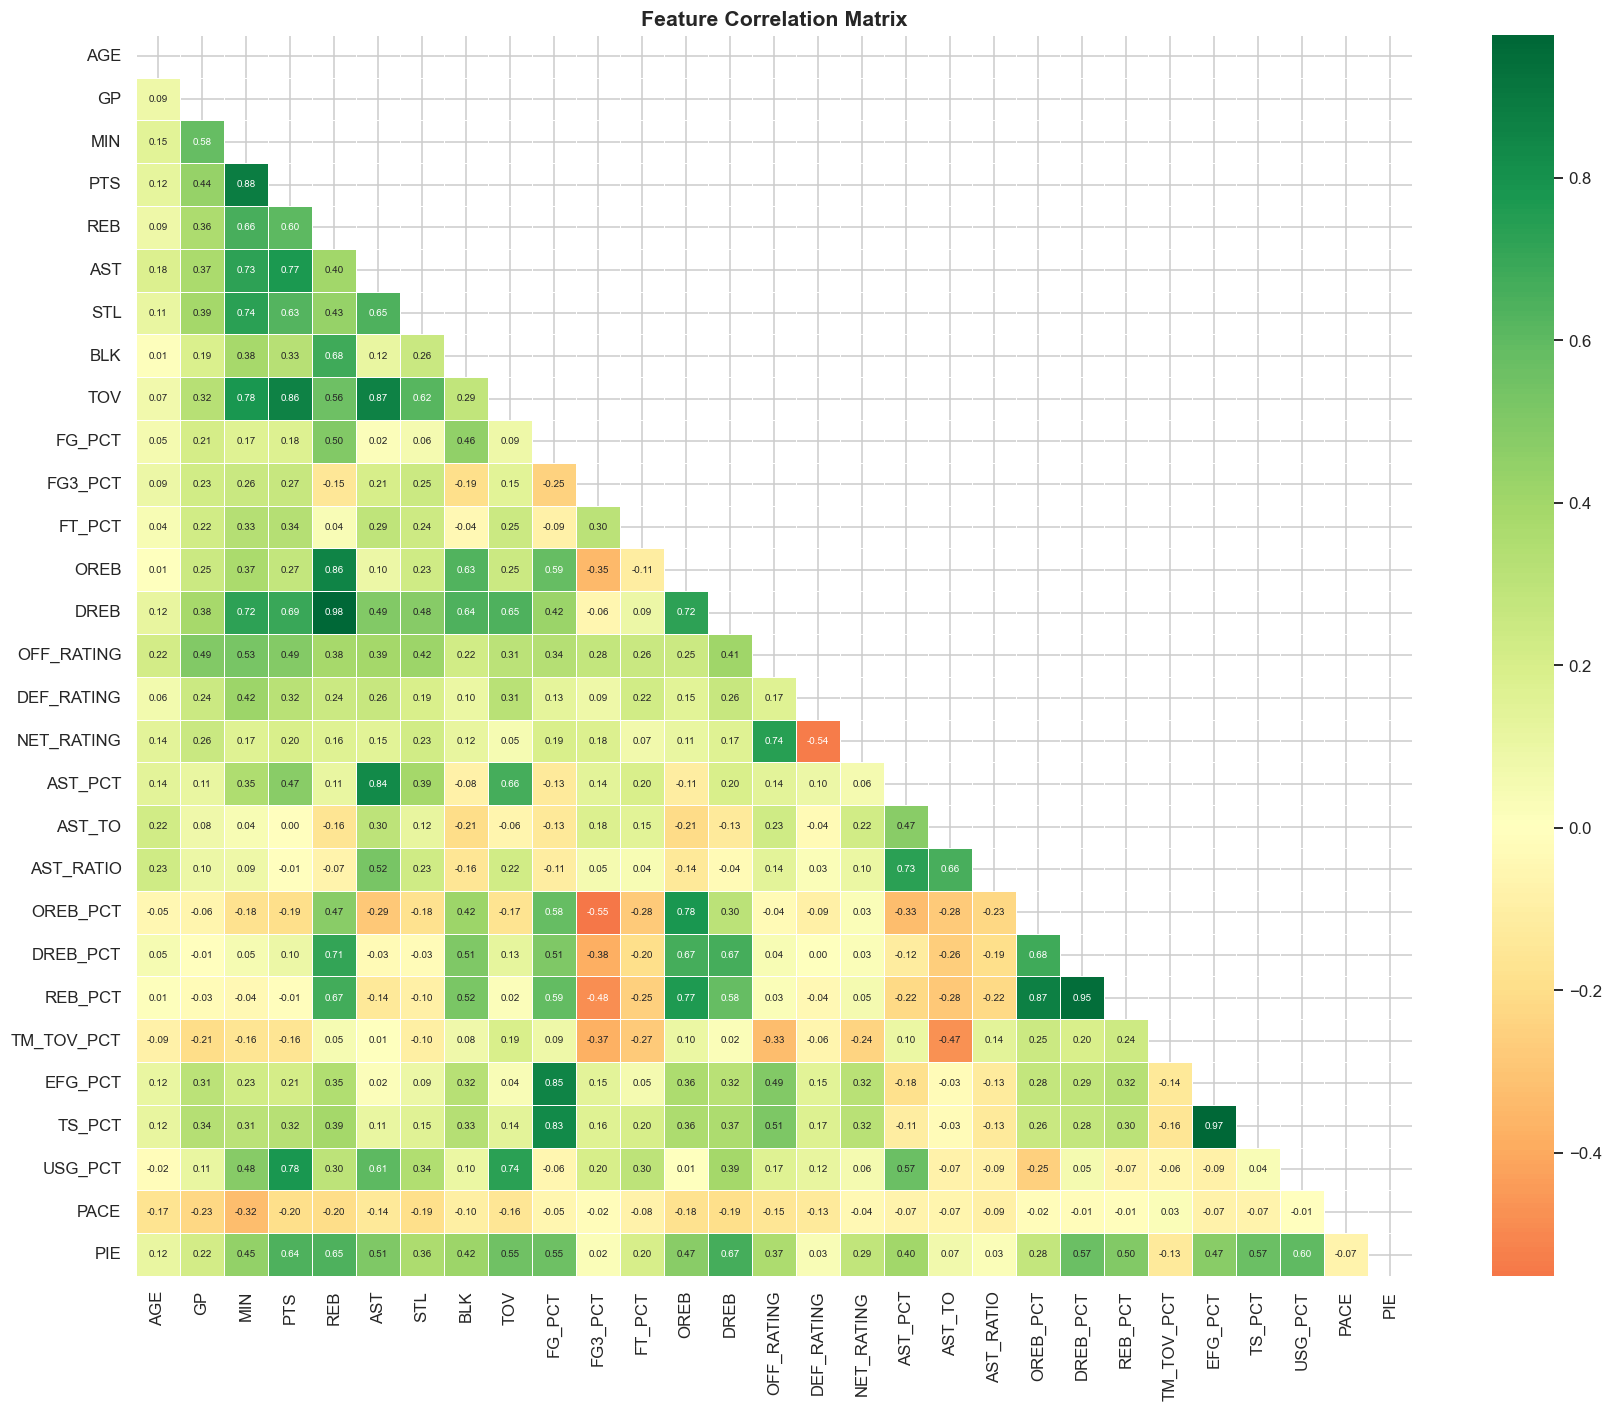

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.drop('PLAYER_ID').tolist()
# exclude POSITION (all NaN)
numeric_cols = [c for c in numeric_cols if df[c].notna().any()]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 6.5}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Highest Correlations with PTS

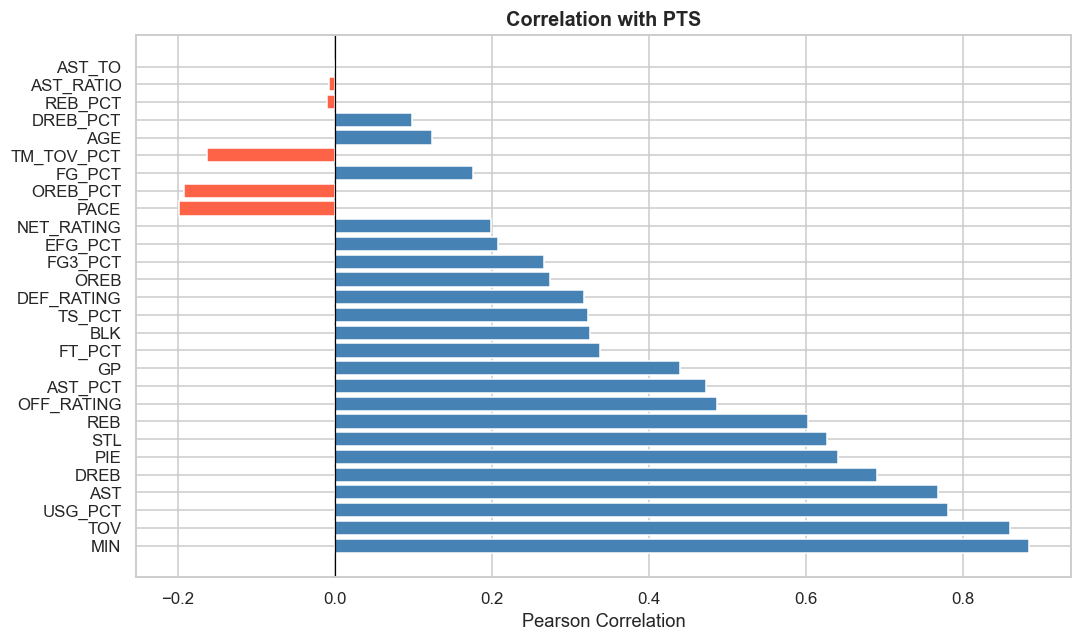

In [7]:
pts_corr = corr['PTS'].drop('PTS').sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v >= 0 else 'tomato' for v in pts_corr]
ax.barh(pts_corr.index, pts_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation')
ax.set_title('Correlation with PTS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Team Analysis

In [8]:
team_stats = df.groupby('TEAM_ABBREVIATION').agg(
    players=('PLAYER_NAME', 'count'),
    avg_pts=('PTS', 'mean'),
    avg_reb=('REB', 'mean'),
    avg_ast=('AST', 'mean'),
    avg_net=('NET_RATING', 'mean'),
    avg_ts=('TS_PCT', 'mean')
).round(2).sort_values('avg_pts', ascending=False)

display(team_stats)

,players,avg_pts,avg_reb,avg_ast,avg_net,avg_ts
TEAM_ABBREVIATION,,,,,,
DET,14,10.97,4.01,2.64,1.46,0.57
PHI,20,10.76,3.82,2.33,-7.03,0.56
SAS,15,10.70,4.13,2.52,-2.85,0.58
TOR,18,10.69,4.27,2.52,-3.43,0.55
ORL,15,10.45,3.97,2.24,-0.20,0.55
UTA,17,10.35,4.43,2.16,-7.33,0.56
BKN,15,10.24,3.75,2.15,-7.65,0.54
CHA,19,10.14,4.21,2.31,-8.88,0.54
NOP,21,9.96,3.97,2.56,-9.74,0.54


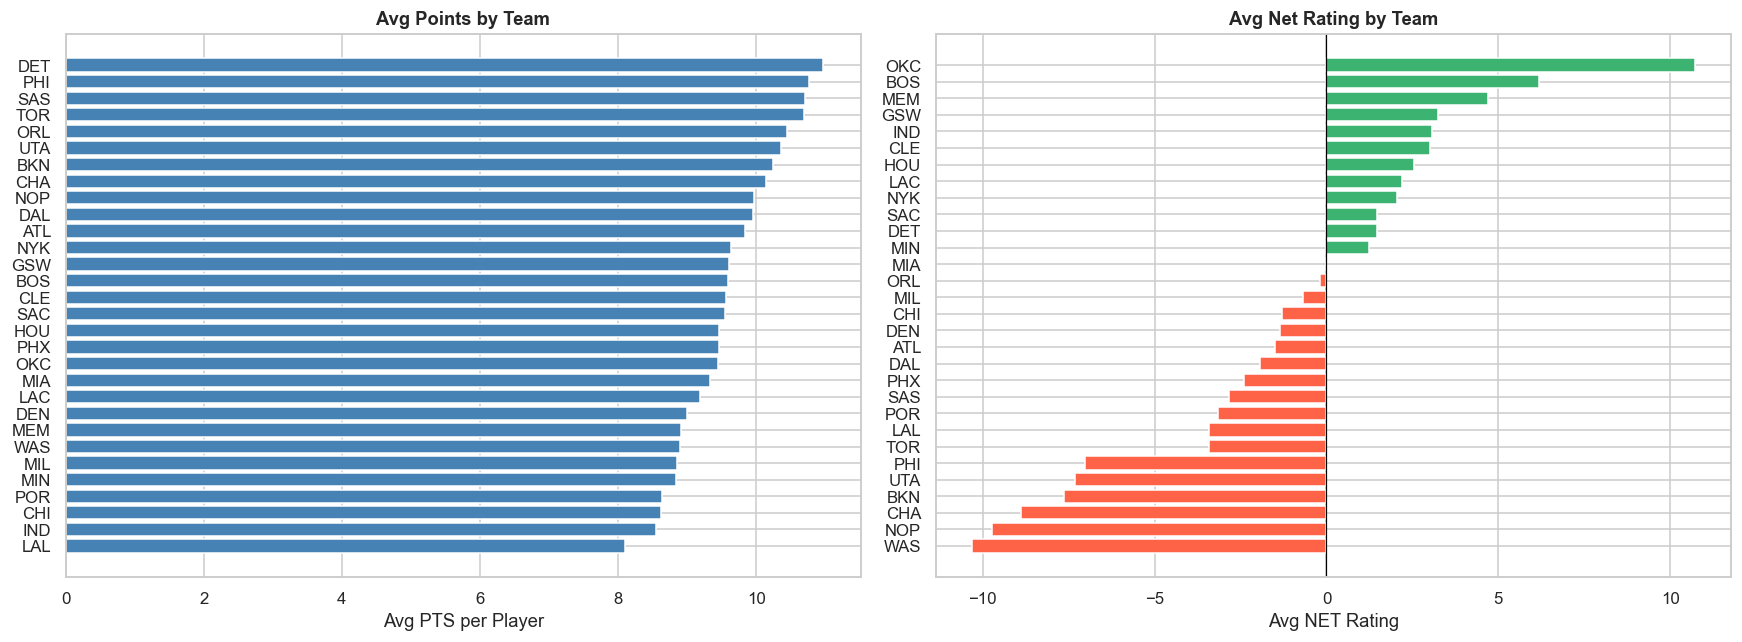

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg points per team
top_pts = team_stats['avg_pts'].sort_values(ascending=True)
axes[0].barh(top_pts.index, top_pts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Avg PTS per Player')
axes[0].set_title('Avg Points by Team', fontweight='bold')

# Avg NET rating per team
net_sorted = team_stats['avg_net'].sort_values(ascending=True)
colors = ['mediumseagreen' if v >= 0 else 'tomato' for v in net_sorted]
axes[1].barh(net_sorted.index, net_sorted.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Avg NET Rating')
axes[1].set_title('Avg Net Rating by Team', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Advanced Stats — Scatter Plots

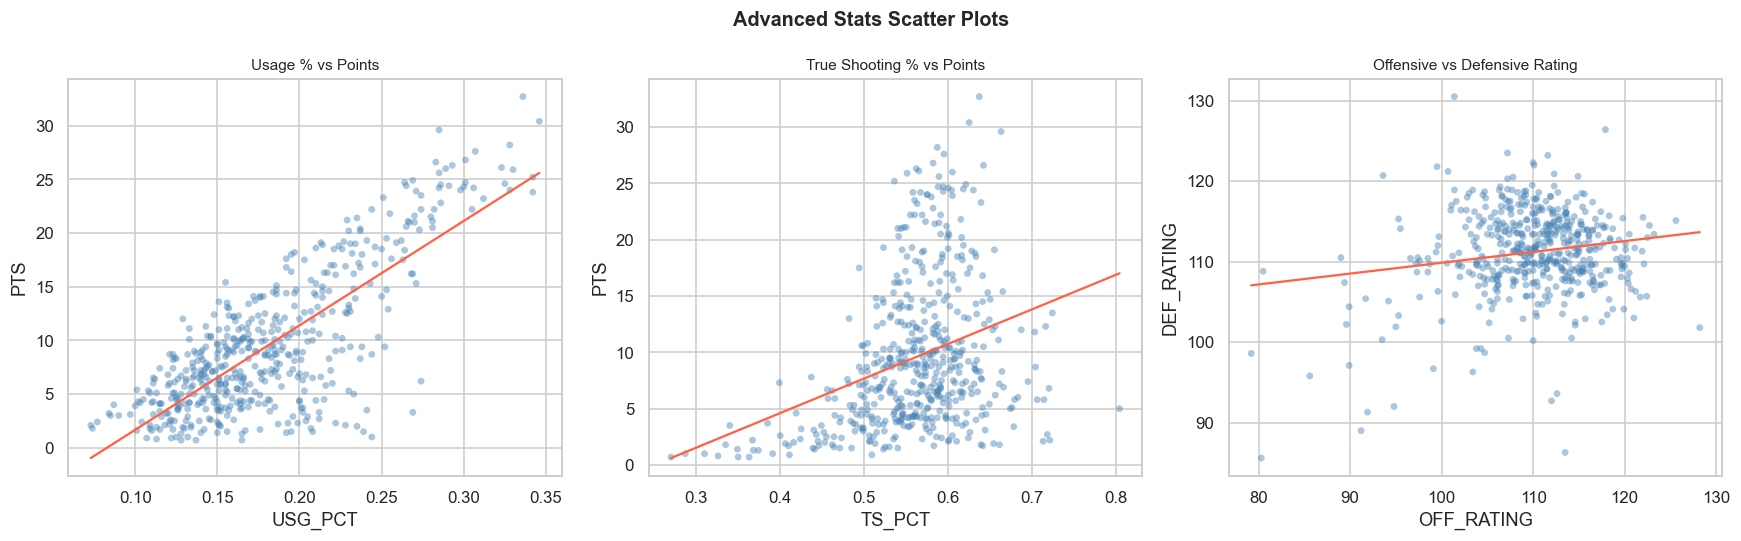

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Advanced Stats Scatter Plots', fontsize=13, fontweight='bold')

pairs = [
    ('USG_PCT', 'PTS', 'Usage % vs Points'),
    ('TS_PCT', 'PTS', 'True Shooting % vs Points'),
    ('OFF_RATING', 'DEF_RATING', 'Offensive vs Defensive Rating'),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.45, s=20, color='steelblue', edgecolors='none')
    # trend line
    valid = df[[x, y]].dropna()
    z = np.polyfit(valid[x], valid[y], 1)
    p = np.poly1d(z)
    xr = np.linspace(valid[x].min(), valid[x].max(), 100)
    ax.plot(xr, p(xr), 'tomato', linewidth=1.5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

## 9. Age Analysis

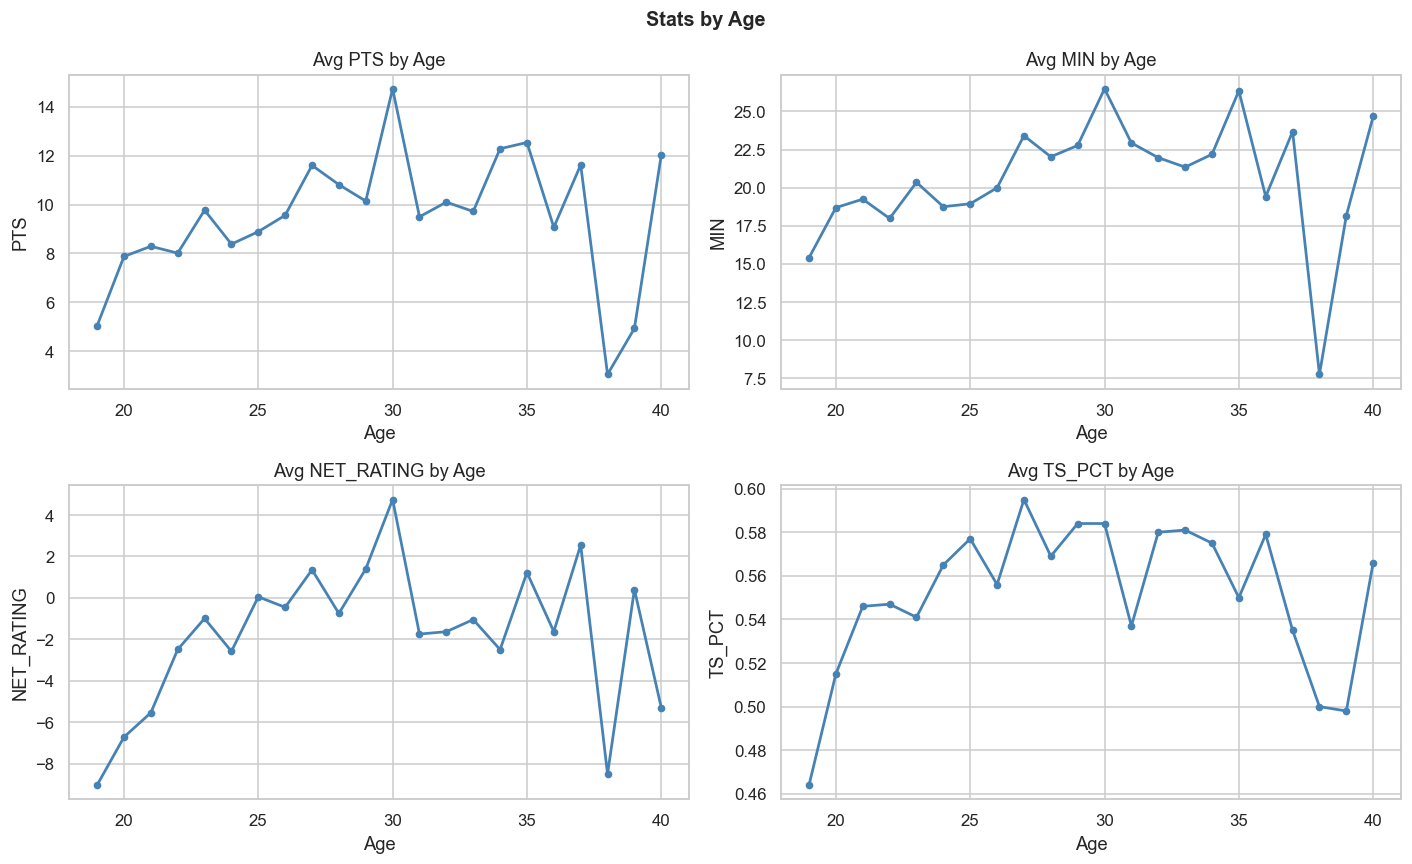

In [12]:
age_stats = df.groupby('AGE')[['PTS', 'MIN', 'NET_RATING', 'TS_PCT']].mean().round(3)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Stats by Age', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, ['PTS', 'MIN', 'NET_RATING', 'TS_PCT']):
    ax.plot(age_stats.index, age_stats[col], marker='o', markersize=4,
            color='steelblue', linewidth=1.8)
    ax.set_xlabel('Age')
    ax.set_ylabel(col)
    ax.set_title(f'Avg {col} by Age')

plt.tight_layout()
plt.show()

## 10. Top 20 Players by Key Stats

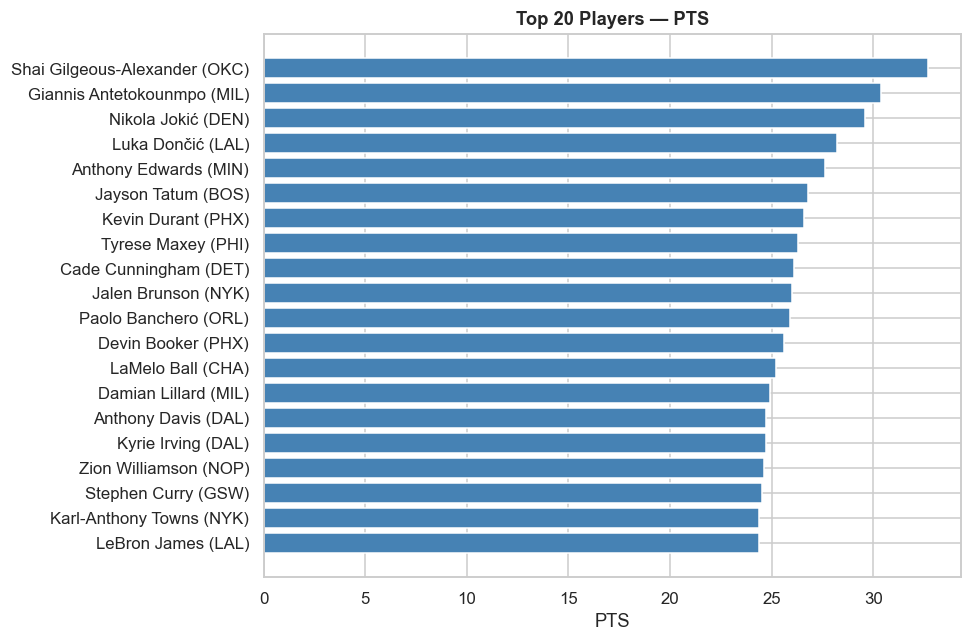

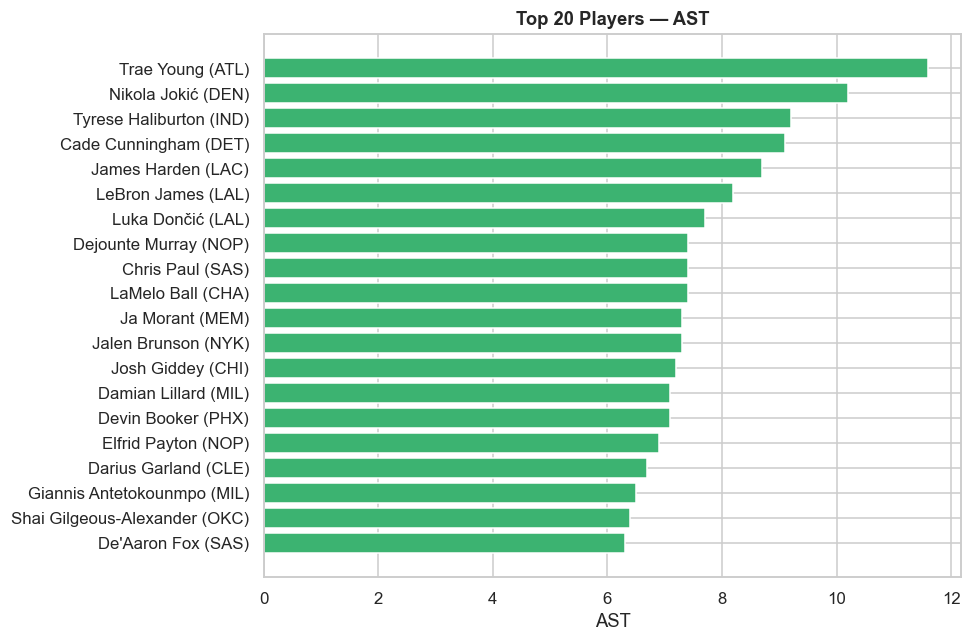

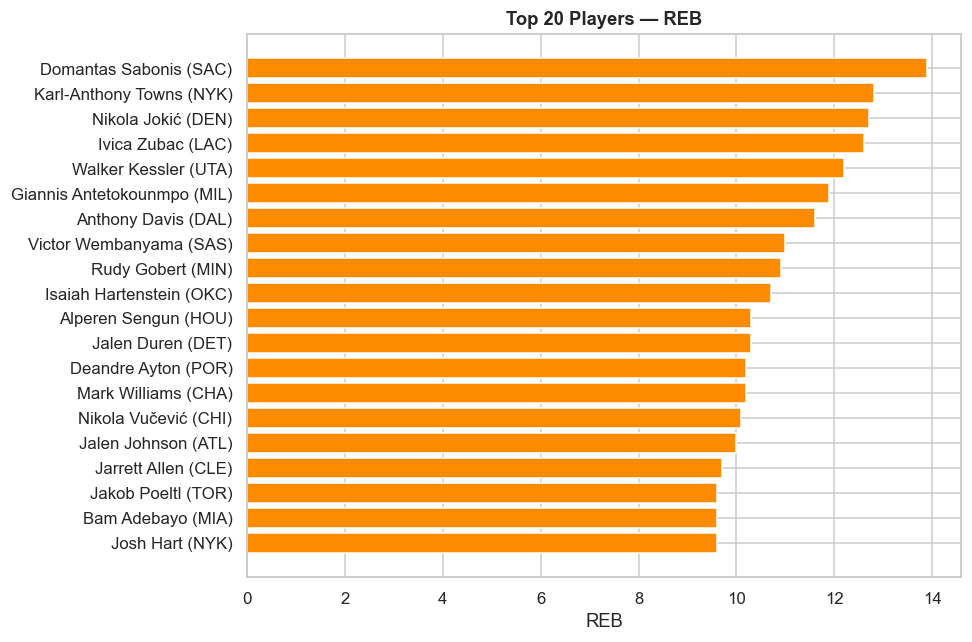

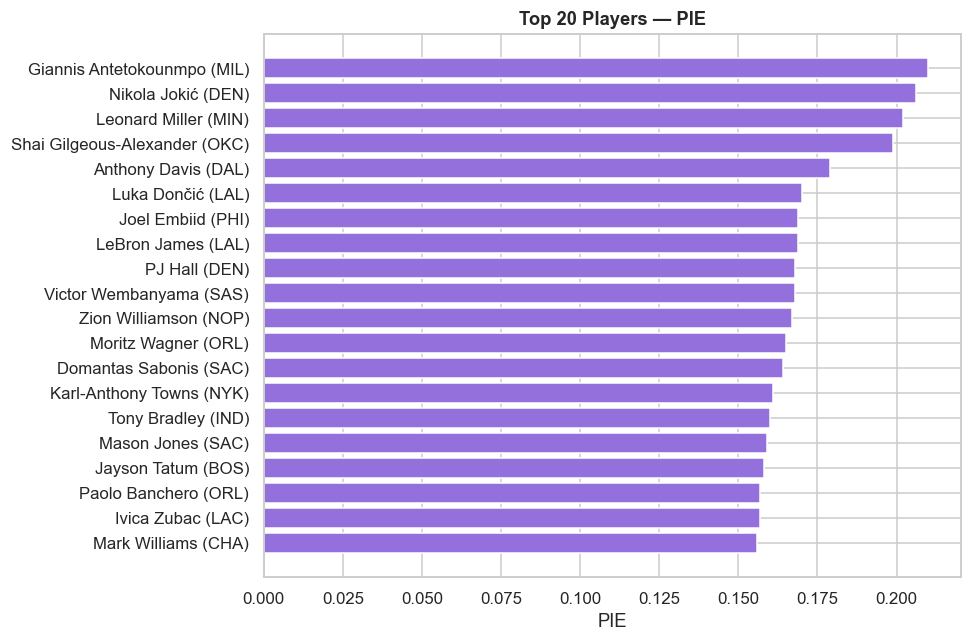

In [13]:
def top20_bar(stat, color='steelblue'):
    top = df.nlargest(20, stat)[['PLAYER_NAME', 'TEAM_ABBREVIATION', stat]]
    top = top.sort_values(stat)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top['PLAYER_NAME'] + ' (' + top['TEAM_ABBREVIATION'] + ')',
            top[stat], color=color, edgecolor='white')
    ax.set_xlabel(stat)
    ax.set_title(f'Top 20 Players — {stat}', fontweight='bold')
    plt.tight_layout()
    plt.show()

top20_bar('PTS', 'steelblue')
top20_bar('AST', 'mediumseagreen')
top20_bar('REB', 'darkorange')
top20_bar('PIE', 'mediumpurple')

## 11. Outlier Detection (IQR)

In [14]:
key_stats = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'MIN', 'TOV']

outlier_rows = []
for col in key_stats:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    out = df[(df[col] > upper) | (df[col] < lower)]
    for _, row in out.iterrows():
        outlier_rows.append({'stat': col, 'player': row['PLAYER_NAME'],
                             'team': row['TEAM_ABBREVIATION'], 'value': row[col]})

outliers_df = pd.DataFrame(outlier_rows).sort_values(['stat', 'value'], ascending=[True, False])
print(f'Total outlier records: {len(outliers_df)}')
display(outliers_df)

Total outlier records: 147


,stat,player,team,value
62,AST,Trae Young,ATL,11.6
57,AST,Nikola Jokić,DEN,10.2
63,AST,Tyrese Haliburton,IND,9.2
35,AST,Cade Cunningham,DET,9.1
50,AST,James Harden,LAC,8.7
...,...,...,...,...
137,TOV,Kevin Durant,PHX,3.1
133,TOV,Jaden Ivey,DET,3.0
136,TOV,Jordan Poole,WAS,3.0
142,TOV,Paolo Banchero,ORL,3.0


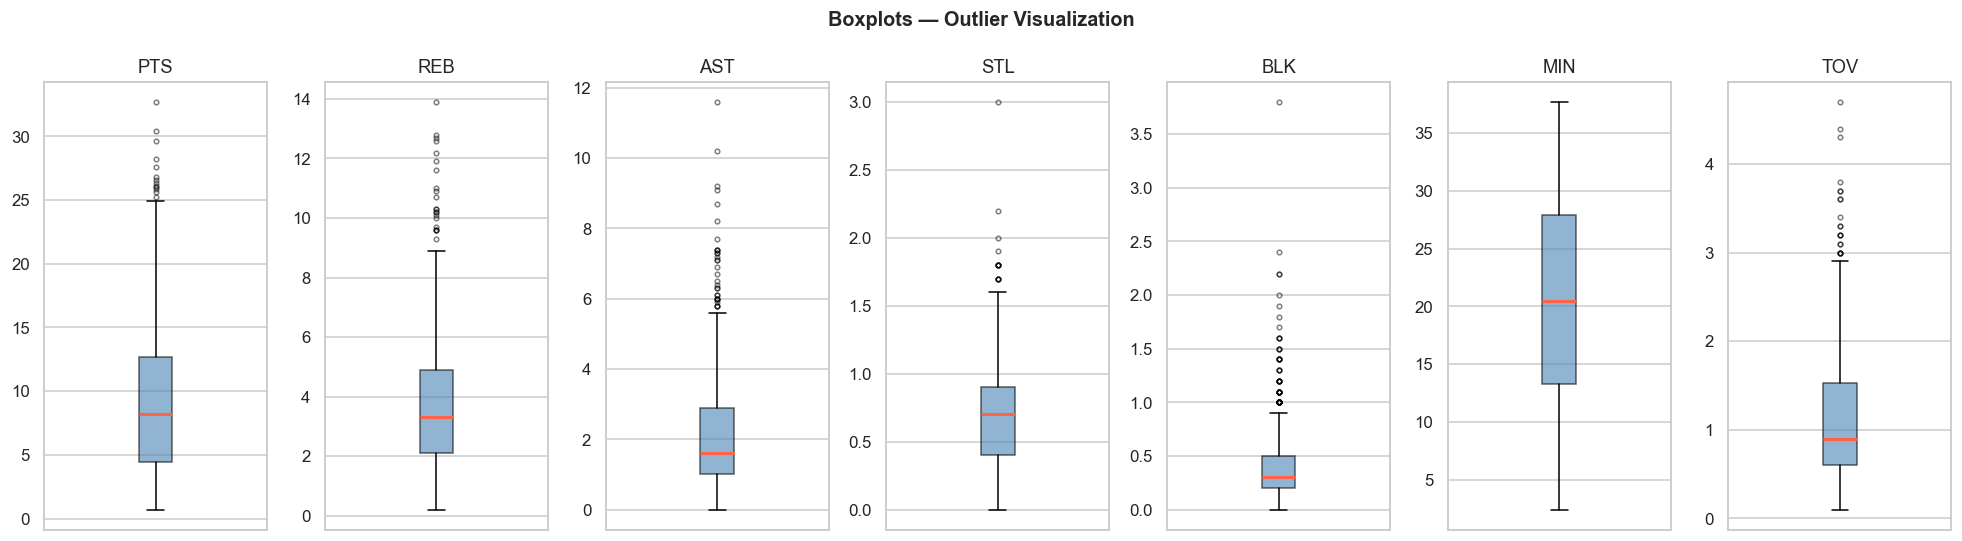

In [15]:
fig, axes = plt.subplots(1, len(key_stats), figsize=(18, 5))
fig.suptitle('Boxplots — Outlier Visualization', fontsize=13, fontweight='bold')

for ax, col in zip(axes, key_stats):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='o', markersize=3, color='gray', alpha=0.5))
    ax.set_title(col)
    ax.set_xticks([])

plt.tight_layout()
plt.show()

## 12. Summary Insights

In [14]:
print('=== KEY FINDINGS ===')
print(f"Dataset: {df.shape[0]} players, {df.shape[1]} features, {df['TEAM_ABBREVIATION'].nunique()} teams")
print(f"Avg age: {df['AGE'].mean():.1f} | Range: {df['AGE'].min():.0f}–{df['AGE'].max():.0f}")
print(f"Avg PTS: {df['PTS'].mean():.1f} | Max scorer: {df.loc[df['PTS'].idxmax(), 'PLAYER_NAME']} ({df['PTS'].max()} PPG)")
print(f"Avg AST: {df['AST'].mean():.1f} | Top playmaker: {df.loc[df['AST'].idxmax(), 'PLAYER_NAME']} ({df['AST'].max()} APG)")
print(f"Avg REB: {df['REB'].mean():.1f} | Top rebounder: {df.loc[df['REB'].idxmax(), 'PLAYER_NAME']} ({df['REB'].max()} RPG)")
print(f"Avg TS%: {df['TS_PCT'].mean():.3f}")
print(f"Avg NET_RATING: {df['NET_RATING'].mean():.2f}")
print(f"\nHighest PIE: {df.loc[df['PIE'].idxmax(), 'PLAYER_NAME']} ({df['PIE'].max():.3f})")
print(f"Missing data: Only POSITION column (100% null) — dropped from analysis.")

=== KEY FINDINGS ===
Dataset: 508 players, 33 features, 30 teams
Avg age: 26.3 | Range: 19–40
Avg PTS: 9.6 | Max scorer: Shai Gilgeous-Alexander (32.7 PPG)
Avg AST: 2.2 | Top playmaker: Trae Young (11.6 APG)
Avg REB: 3.8 | Top rebounder: Domantas Sabonis (13.9 RPG)
Avg TS%: 0.561
Avg NET_RATING: -1.27

Highest PIE: Giannis Antetokounmpo (0.210)
Missing data: Only POSITION column (100% null) — dropped from analysis.
